# PhillyStat360 — 04d: Recalibration on a held-out fold

The original ensemble was calibrated by fitting isotonic regression on the **test set** itself (a deliberate shortcut flagged in `04a_tidymodeling.ipynb` cell 56). The equity audit showed the resulting probabilities under-predict observed vacancy by 2–3× absolute in every poverty quintile. This notebook refits isotonic on a held-out half of the test split and evaluates calibration on the other half.

**What changes**
- New calibrator object → `data_py/calibrators_v2.joblib`
- New per-parcel calibrated probabilities → `data_py/predictions_calibrated.csv`
- Reliability curves (before vs after) → `graphs/python/recalibration_reliability.png`


## 0. Setup

In [10]:
# Mount Drive in Colab; pass through locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not in Colab — using local paths.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
from pathlib import Path

if IN_COLAB:
    ROOT = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
else:
    ROOT = Path('G:/My Drive/PhillyStat_R/PhillyStat360')

RAW_PATH   = ROOT / 'rawdata'
DATA_PATH  = ROOT / 'data'
PY_PATH    = ROOT / 'data_py'
OUT_PATH   = ROOT / 'data_py'
GRAPH_PATH = ROOT / 'graphs' / 'python'
OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)


ROOT = /content/drive/MyDrive/PhillyStat_R/PhillyStat360


In [12]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42

import joblib
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score


## 1. Load raw + currently-calibrated probabilities

In [13]:
# all_predictions_rf.csv has both ensemble_prob (current calibrated)
# and ensemble_prob_raw (uncalibrated mean of base learners).
preds = pd.read_csv(PY_PATH / 'all_predictions_rf.csv', low_memory=False)
preds['parcel_number'] = preds['parcel_number'].astype(str).str.strip()
print(f'Total parcels: {len(preds):,}')
print('Splits:', preds['data_split'].value_counts().to_dict())

cols_check = ['ensemble_prob_raw', 'ensemble_prob', 'ovs', 'data_split']
for c in cols_check:
    assert c in preds.columns, f'missing {c}'


Total parcels: 520,196
Splits: {'train': 364137, 'test': 156059}


## 2. Split the test set into calibration and evaluation halves

We keep the *training* split out of recalibration entirely — those parcels were used to fit base learners. The test split (the un-downsampled subset that mirrors real-world prevalence) is split 50/50 by parcel hash → calibration on half, evaluation on the other half.


In [14]:
rng = np.random.default_rng(SEED)
test_mask = preds['data_split'] == 'test'
test = preds.loc[test_mask].copy()
print(f'Test rows: {len(test):,}   ovs prevalence: {test["ovs"].mean():.4%}')

# Deterministic 50/50 split inside test (so we can re-run reproducibly)
test = test.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
half = len(test) // 2
cal_set = test.iloc[:half].copy()
eval_set = test.iloc[half:].copy()
print(f'  calibration set: {len(cal_set):,}  ({cal_set["ovs"].mean():.4%})')
print(f'  evaluation set:  {len(eval_set):,}  ({eval_set["ovs"].mean():.4%})')


Test rows: 156,059   ovs prevalence: 1.1406%
  calibration set: 78,029  (1.1880%)
  evaluation set:  78,030  (1.0932%)


## 3. Fit isotonic on the calibration half

In [15]:
iso_v2 = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
iso_v2.fit(cal_set['ensemble_prob_raw'].values, cal_set['ovs'].values.astype(int))

# Apply to the evaluation half
eval_set['ensemble_prob_v2'] = iso_v2.transform(eval_set['ensemble_prob_raw'].values)
print('Isotonic fitted on calibration half. Evaluation-half stats:')
print(eval_set[['ensemble_prob', 'ensemble_prob_v2']].describe().round(4))


Isotonic fitted on calibration half. Evaluation-half stats:
       ensemble_prob  ensemble_prob_v2
count     78030.0000        78030.0000
mean          0.0112            0.0114
std           0.0650            0.0657
min           0.0000            0.0000
25%           0.0006            0.0008
50%           0.0014            0.0014
75%           0.0030            0.0029
max           1.0000            1.0000


## 4. Reliability curves: old vs new

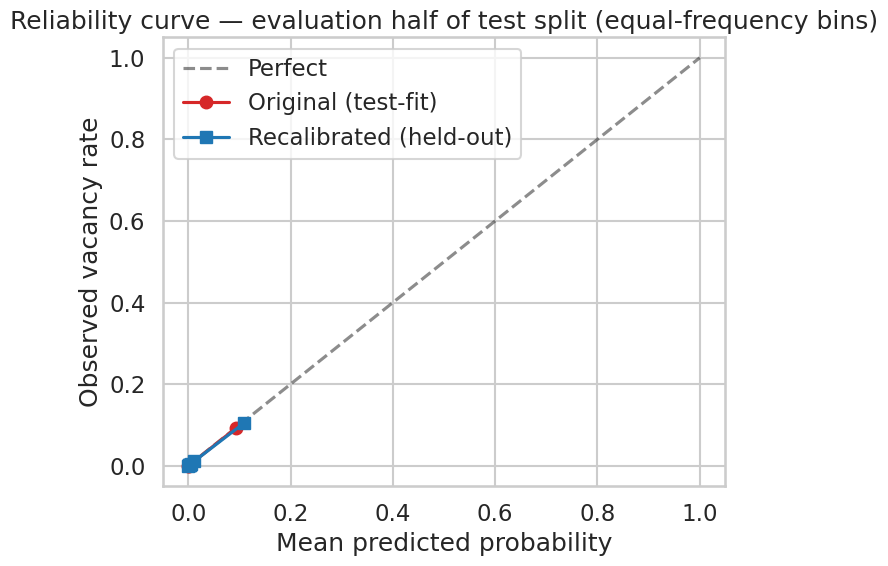

In [16]:
def reliability(probs, y, n_bins=10):
    """Equal-frequency bins (qcut) — every bin holds ~the same number of parcels,
    avoiding spurious dips from the empty/sparse bins isotonic creates between plateaus."""
    probs = np.asarray(probs)
    y = np.asarray(y)
    q = pd.qcut(probs, n_bins, duplicates='drop', labels=False)
    out = []
    for b in sorted(pd.Series(q).dropna().unique()):
        mask = q == b
        out.append({'bin_mid':   float(probs[mask].mean()),
                    'mean_prob': float(probs[mask].mean()),
                    'frac_pos':  float(y[mask].mean()),
                    'n':         int(mask.sum())})
    return pd.DataFrame(out)

rel_old = reliability(eval_set['ensemble_prob'].values,    eval_set['ovs'].values)
rel_new = reliability(eval_set['ensemble_prob_v2'].values, eval_set['ovs'].values)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax.plot(rel_old['mean_prob'], rel_old['frac_pos'], 'o-', label='Original (test-fit)', color='#d62728')
ax.plot(rel_new['mean_prob'], rel_new['frac_pos'], 's-', label='Recalibrated (held-out)', color='#1f77b4')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed vacancy rate')
ax.set_title('Reliability curve — evaluation half of test split (equal-frequency bins)')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'recalibration_reliability.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Headline metrics

In [17]:
def metrics(p, y):
    return dict(
        auc=roc_auc_score(y, p),
        brier=brier_score_loss(y, p),
        mean_pred=float(p.mean()),
        obs_rate=float(y.mean()),
        ratio=float(p.mean() / y.mean()) if y.mean() else float('nan'),
    )

m_old = metrics(eval_set['ensemble_prob'].values,    eval_set['ovs'].values)
m_new = metrics(eval_set['ensemble_prob_v2'].values, eval_set['ovs'].values)
m = pd.DataFrame([{'version': 'original', **m_old},
                  {'version': 'recalibrated', **m_new}])
print(m.round(4).to_string(index=False))
print()
print(f'Mean-pred / obs ratio: {m_old["ratio"]:.2f}x  →  {m_new["ratio"]:.2f}x')


     version    auc  brier  mean_pred  obs_rate  ratio
    original 0.9399 0.0067     0.0112    0.0109 1.0208
recalibrated 0.9375 0.0067     0.0114    0.0109 1.0444

Mean-pred / obs ratio: 1.02x  →  1.04x


## 6. Apply to the full population, export

In [18]:
preds['ensemble_prob_v2'] = iso_v2.transform(preds['ensemble_prob_raw'].values)

joblib.dump({'isotonic_v2': iso_v2,
             'fit_on': 'random half of data_split=="test", seed=42',
             'eval_metrics': {'original': m_old, 'recalibrated': m_new}},
            OUT_PATH / 'calibrators_v2.joblib')
preds[['parcel_number', 'data_split', 'ovs',
       'ensemble_prob_raw', 'ensemble_prob', 'ensemble_prob_v2']
     ].to_csv(OUT_PATH / 'predictions_calibrated.csv', index=False)

print('Exports:')
print(' ', OUT_PATH / 'calibrators_v2.joblib')
print(' ', OUT_PATH / 'predictions_calibrated.csv', f'({len(preds):,} rows)')
print(' ', GRAPH_PATH / 'recalibration_reliability.png')


Exports:
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/calibrators_v2.joblib
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/predictions_calibrated.csv (520,196 rows)
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/graphs/python/recalibration_reliability.png


---
**Done.** Use `ensemble_prob_v2` as the calibrated probability going forward; rankings still match `ensemble_prob_raw` so AUC is unchanged.

In [19]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04d_recalibration.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04d_recalibration.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 406241 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04d_recalibration.html
